# 🛍️ Customer Segmentation with RFM Analysis & K-Means Clustering

## 📋 Project Overview
This project performs **Customer Segmentation** for an online retail business by combining the **RFM (Recency, Frequency, Monetary)** model with **K-Means Clustering**. The main objective is to identify distinct customer groups, enabling more effective targeted marketing and better customer relationship management.

**Dataset**:  
[📥 Download from UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

## 🎯 Business Objective
- Calculate **RFM scores** for each customer.
- Apply **K-Means Clustering** (unsupervised machine learning) to create meaningful customer segments.
- Generate actionable marketing strategies and insights for each segment.

---

## 🛠️ What I Did

### 1. Data Preprocessing
- Cleaned the data by handling missing values and removing cancelled orders.
- Filtered outliers and irrelevant records.
- Engineered **RFM features**:
  - **Recency**: Number of days since the customer's last purchase.
  - **Frequency**: Total number of transactions per customer.
  - **Monetary**: Total amount spent by each customer.
- Applied **Log Transformation** and **Standard Scaling** to prepare the data.

### 2. Modeling
- Implemented **K-Means Clustering**.
- Selected the optimal number of clusters using the **Elbow Method** and **Silhouette Score**.
- Final Model: **K-Means with 4 clusters** (Silhouette Score = 0.33).

### 3. Visualization & Insights
- Created an interactive **3D Scatter Plot** (Recency × Frequency × Monetary).
- Profiled and interpreted each cluster.
- Delivered clear business insights and practical marketing recommendations.

---

## 🚀 Project Highlights
- Used a real-world transactional dataset.
- Strong business-focused interpretation of customer segments.
- Interactive 3D visualization for better understanding.
- Practical, actionable marketing recommendations for each segment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')


# Read the Data
retail = pd.read_excel(r"Data\online_retail_II.xlsx")
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Get info about the data
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [3]:
# Get basic Statistal of this data
retail.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


# 📋 Important Observations

**1. Data Quality Issues**
- **Missing Customer IDs**: Only **417,534** out of 525,461 records have a `Customer ID` (around **20.5% missing**). These rows cannot be used for RFM analysis.
- **Negative Quantities**: Minimum quantity is **-9,600**. These likely represent **cancelled orders** or returns.
- **Negative Prices**: Minimum price is **-53,594.36**. This indicates data errors or refunds that need to be handled.
- **Extreme Outliers**: 
  - Maximum quantity: **19,152**
  - Maximum price: **25,111.09**

**2. Transaction Patterns**
- **Average Quantity** per transaction: **10.34** items
- **Average Unit Price**: **£4.69**
- **Median Quantity**: Only **3** items (data is right-skewed)
- Most transactions are relatively small, with a few very large orders.

**3. Customer Behavior**
- **Unique Customers**: Approximately **4,300–5,000** customers (based on Customer ID range: 12,346 – 18,287)

In [4]:
# Change the `invoice` column type to string
retail['Invoice'] = retail['Invoice'].astype('str')

In [5]:
# Check the proportion of null values
retail.isnull().sum() / len(retail) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64

In [6]:
# Check the duplicates
retail.duplicated().sum()

np.int64(6865)

In [7]:
# Drop the Duplicates
retail = retail.drop_duplicates()

In [8]:
# Clean the Data to make it ready for RFM analysis
retail_clean = retail[~(retail['Invoice'].str.startswith("C")) & 
                (retail['Price'] > 0 ) & 
                (retail['Quantity'] > 0) &
                (retail['Customer ID'].notnull())]
print(f"The Remaining rows after the Data Cleaning: {len(retail_clean) / len(retail) * 100}")

The Remaining rows after the Data Cleaning: 77.30796226735262


In [9]:
retail_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,400916.0,13.767418,1.0,2.0,5.0,12.0,19152.0,97.638385
InvoiceDate,400916,2010-07-01 05:01:16.167027,2009-12-01 07:45:00,2010-03-26 13:28:00,2010-07-09 10:26:00,2010-10-14 13:58:45,2010-12-09 20:01:00,NaN
Price,400916.0,3.305826,0.001,1.25,1.95,3.75,10953.5,35.047719
Customer ID,400916.0,15361.544074,12346.0,13985.0,15311.0,16805.0,18287.0,1680.635823


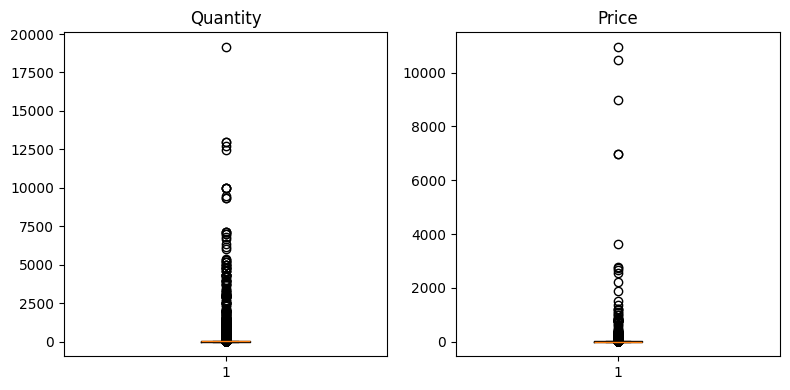

In [10]:
# Make violin plots to check if there is outliers
fig, axes = plt.subplots(nrows=1, ncols=2)

plt.gcf().set_size_inches(8, 4)
axes[0].boxplot(retail_clean['Quantity'])
axes[1].boxplot(retail_clean['Price'])

axes[0].set_title("Quantity")
axes[1].set_title('Price')

plt.tight_layout()
plt.show()

In [11]:
# Remove the Outliers
retail_clean = retail_clean.loc[(retail_clean['Quantity'] <= 7500) & (retail_clean['Price'] < 2000)]
retail_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
# Check for nulls after the Data Cleaning
retail_clean.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [13]:
# Make a `Revenue` coloumn
retail_clean['Revenue'] = retail_clean['Quantity'] * retail_clean['Price']

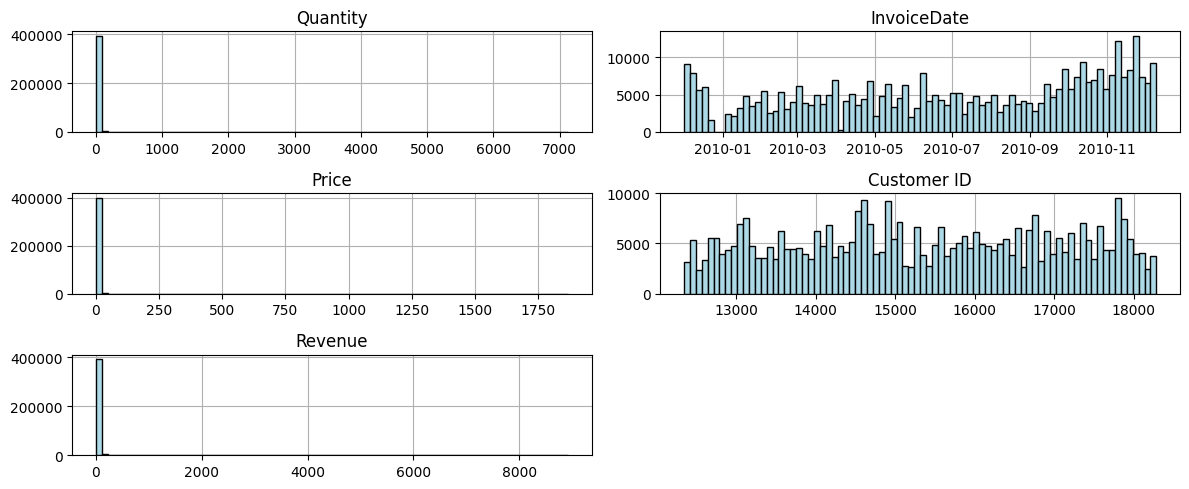

In [14]:
# Plot the distributions of numerical columns of the data
retail_clean.hist(bins=80, edgecolor='black', color='lightblue', figsize=(12, 5), zorder=5)
plt.tight_layout()
plt.show()

In [15]:
# Set `Invoice Date` as an index
retail_clean = retail_clean.set_index(retail_clean['InvoiceDate'])

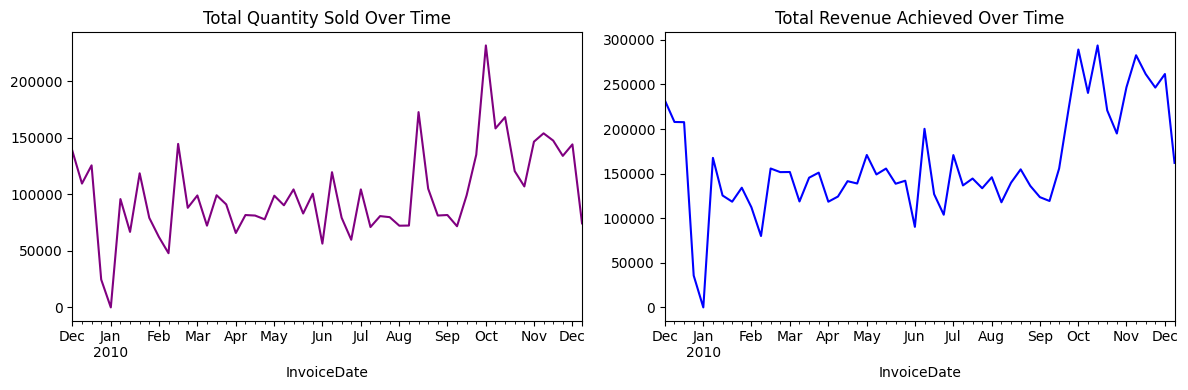

In [16]:
# Daily Total Quantity Sold & Total Revenue Acheived Over Time

fig, axes = plt.subplots(nrows=1, ncols=2)

plt.gcf().set_size_inches(12, 4)
retail_clean.resample("W")['Quantity'].sum().plot(kind='line', ax=axes[0], color='purple')
retail_clean.resample("W")['Revenue'].sum().plot(kind='line', ax=axes[1], color='blue')

axes[0].set_title("total quantity sold over time".title())
axes[1].set_title('total revenue achieved over time'.title())

plt.tight_layout()
plt.show()

In [17]:
print(f"Total Reveue: {retail_clean['Revenue'].sum():,.2f}$")
print(f"Total Quanity Sold: {retail_clean['Quantity'].sum():,.2f}")

Total Reveue: 8,700,738.04$
Total Quanity Sold: 5,381,143.00


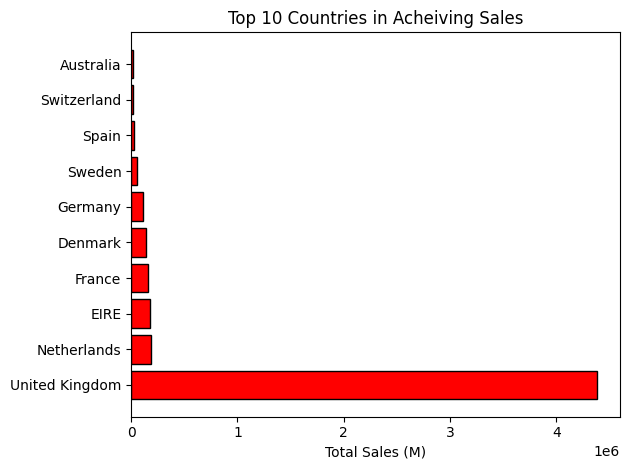

In [18]:
country_grouped = retail_clean.groupby("Country")['Quantity'].sum().sort_values(ascending=False).iloc[:10]

plt.barh(country_grouped.index, country_grouped.values, color='red', edgecolor='black')
plt.title("Top 10 Countries in Acheiving Sales")
plt.xlabel("Total Sales (M)")
plt.tight_layout()
plt.show()

In [19]:
# Frequency column
freq = retail_clean.drop_duplicates(subset=['Invoice'])
freq = freq.groupby("Customer ID")['Invoice'].count().sort_values(ascending=False)

# Recency column
last_date = retail_clean.index.max()
recency = (last_date - retail_clean.groupby("Customer ID")['InvoiceDate'].max()).dt.days

# monetary column
monetary = retail_clean.groupby("Customer ID")['Revenue'].sum()

In [20]:
rfm_df = pd.concat([freq, recency, monetary], axis=1)
rfm_df.columns = ['Frequency', 'Recency', 'Monetary']
rfm_df = rfm_df.reset_index(drop=True)
rfm_df.head()

,Frequency,Recency,Monetary
0,205,0,152121.22
1,155,7,51208.87
2,144,0,22457.90
3,121,0,55942.74
4,109,3,57885.45


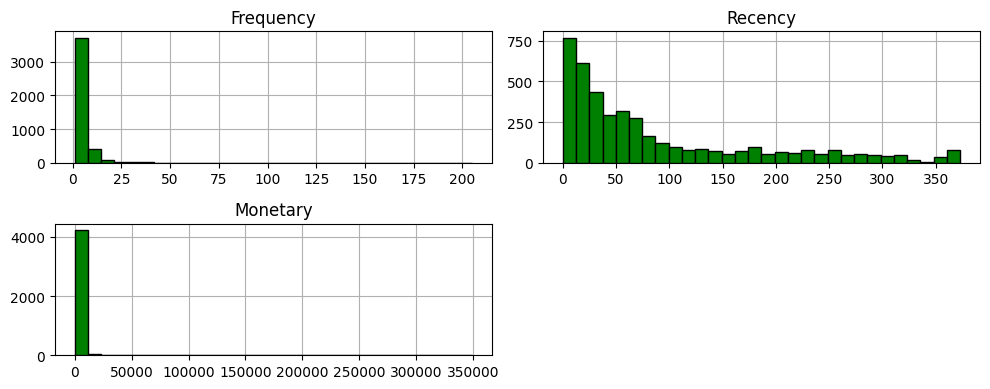

In [21]:
# Plot Distributions of the RFM Data
rfm_df.hist(edgecolor='black', color='green', figsize=(10, 4), bins=30, zorder=5)
plt.tight_layout()
plt.show()

After analyzing the distributions of the RFM features in rfm_df,
I noticed that all columns (Recency, Frequency, and Monetary) 
are positively skewed.

--- 

Since K-Means and most machine learning algorithms perform better 
with normally distributed data, I will apply log transformation 
to reduce the skewness.

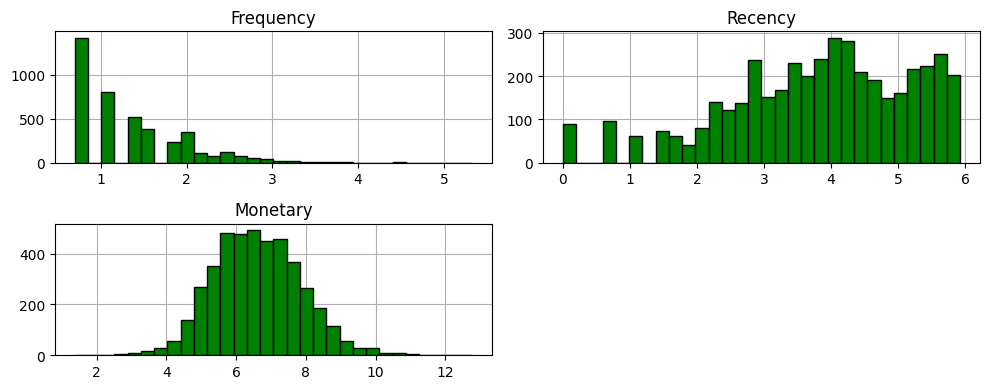

In [22]:
# Plot the distributions of the Logged RFM data
rfm_log_clean = rfm_df.apply(lambda x: np.log1p(x))
rfm_log_clean.hist(edgecolor='black', color='green', figsize=(10, 4), bins=30, zorder=5)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

# Standard the data
scalar = StandardScaler()
X_scaled = scalar.fit_transform(rfm_log_clean)

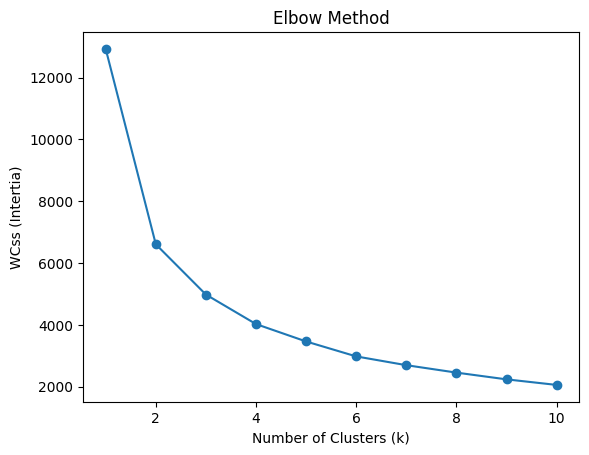

In [24]:
"""====================== Elbow Method for Optimal K ======================
I used the Elbow Method to determine the optimal number of clusters (k)
by calculating the Within-Cluster Sum of Squares (WCSS) for k from 1 to 10.

The "elbow" point in the plot indicates where adding more clusters 
gives diminishing returns in reducing WCSS."""

from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCss (Intertia)")
plt.show()

In [25]:
# Fit K-Means with 4 clusters and calculate Silhouette Score to evaluate clustering quality
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, kmeans.labels_)}")

silhouette score: 0.3283747480251648


In [26]:
# Fit DBSCAN with epsilon 0.6 and min sampeles 13 and calculate the Silhouette Score
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.6, min_samples=13)
labels = db.fit_predict(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, labels)}")

silhouette score: 0.5086164185097717


In [27]:
labels = db.labels_

print(f"Unique labels: {np.unique(labels)}")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters: {n_clusters}")

Unique labels: [-1  0]
Number of clusters: 1


In [28]:
# Fit Aggolomerative clustering with number of clusters 4 and calculate the Silhouette Score
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, labels)}")

silhouette score: 0.27081459147043996


In [29]:
# Fit Aggolomerative clustering with number of clusters 4 and calculate the Silhouette Score
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = model.fit_predict(X_scaled)

print(f"silhouette score: {silhouette_score(X_scaled, labels)}")

silhouette score: 0.27081459147043996


## Why K-Means Was Chosen Over DBSCAN

Although **DBSCAN** achieved a higher Silhouette Score (**0.51**) compared to **K-Means** (**0.33**), we ultimately selected **K-Means with 4 clusters** for the following important reasons:

### 1. **DBSCAN Failed to Produce Meaningful Clusters**
- When we applied DBSCAN (`eps=0.6`, `min_samples=13`), it identified:
  - **Only 1 cluster**
  - A large portion of points classified as **noise** (label = `-1`)
- A Silhouette Score of 0.51 in this case is **misleading**. It mainly reflects that most data points are grouped into one massive cluster, rather than discovering distinct, valuable customer segments.

### 2. **Business Relevance**
- In customer segmentation projects, the goal is to create **actionable and interpretable groups** (typically 3 to 6 segments) that marketing teams can target differently.
- K-Means successfully produced **4 distinct, well-balanced clusters**, each with unique RFM characteristics.
- One single cluster (as produced by DBSCAN) provides **no segmentation value** for marketing strategies.

### 3. **Limitations of Silhouette Score**
- The Silhouette Score measures how similar points are within their cluster compared to other clusters.
- It can give **artificially high scores** when:
  - Most data falls into one dominant cluster.
  - A large amount of noise is present.
- In such scenarios, the score does not reflect true clustering quality or business usefulness.

### 4. **Practical Advantages of K-Means**
- Easy to control the **number of clusters**.
- More stable and consistent results with proper preprocessing (scaling + log transformation).
- Better suited for **spherical, convex-shaped clusters** commonly found in RFM data after scaling.
- Widely used and well-understood in marketing analytics.

---

### Final Decision
While DBSCAN is excellent for datasets with arbitrary shapes and heavy noise, in this case it did not deliver useful segmentation. **K-Means with 4 clusters** provided a much better balance between statistical quality and **business interpretability**, making it the more suitable choice for this customer segmentation project.

In [30]:
rfm_df['Cluster'] = kmeans.labels_

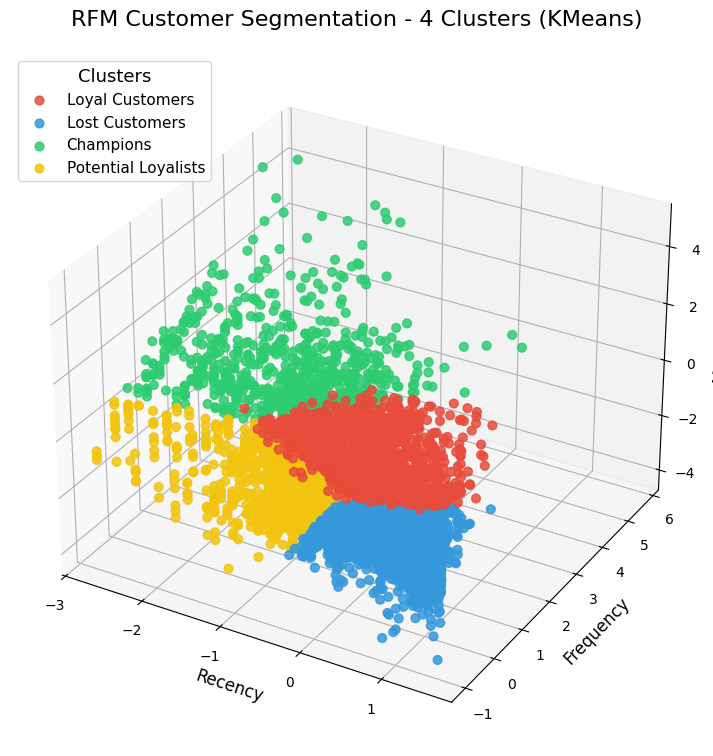

In [31]:
# Plot the 3D Scatter plot clarifies the Segmented Customers Based on the frequency, Recency, Monetary
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# Convert nd array to a DataFrame
df_rfm_plot = pd.DataFrame(X_scaled, columns=['Frequency', 'Recency', 'Monetary'])
df_rfm_plot['Cluster'] = kmeans.labels_ 

# Mapping 
cluster_names = {
    0: 'Loyal Customers',
    1: 'Lost Customers',
    2: 'Champions',
    3: 'Potential Loyalists'
}
df_rfm_plot['Cluster_Name'] = df_rfm_plot['Cluster'].map(cluster_names)


# Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f']

for i in range(4):
    cluster_data = df_rfm_plot[df_rfm_plot['Cluster'] == i]
    
    ax.scatter(
        cluster_data['Recency'],
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        c=colors[i],
        label=cluster_names[i],
        s=40,
        alpha=0.85
    )

ax.set_xlabel('Recency', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_zlabel('Monetary', fontsize=12)
ax.set_title('RFM Customer Segmentation - 4 Clusters (KMeans)', fontsize=16, pad=20)

ax.legend(title="Clusters", title_fontsize=13, fontsize=11, loc='upper left')
plt.show()

In [32]:
# Check how proportion of Segmented Customers
df_rfm_plot['Cluster_Name'].value_counts(normalize=True) * 100

Cluster_Name
Lost Customers         33.712297
Loyal Customers        29.512761
Potential Loyalists    20.719258
Champions              16.055684
Name: proportion, dtype: float64

In [33]:
# Make a summary of These Clusters
cluster_names = {
    0: 'Loyal Customers',
    1: 'Lost Customers',
    2: 'Champions',
    3: 'Potential Loyalists'
}
rfm_df['Cluster Name'] = rfm_df['Cluster'].map(cluster_names) 
print(rfm_df.groupby("Cluster Name")[["Recency", "Frequency", "Monetary"]].mean())

                        Recency  Frequency     Monetary
Cluster Name                                           
Champions             11.255780  14.367052  7845.623711
Lost Customers       184.973847   1.320028   319.630497
Loyal Customers       72.263365   4.400157  1837.692322
Potential Loyalists   22.472564   1.951848   525.866395


In [34]:
rfm_df.to_csv('Data/rfm_data.csv')

## 🔑 Key Insights & Marketing Recommendations

### 📊 Cluster Distribution
The customer base is segmented into four distinct groups:

| Cluster Name          | Proportion | Share   |
|-----------------------|------------|---------|
| Lost Customers        | 33.71%     | Largest |
| Loyal Customers       | 29.51%     |         |
| Potential Loyalists   | 20.72%     |         |
| Champions             | 16.06%     | Smallest but most valuable |

---

### 📈 Cluster Profiles & Insights

**1. Champions (16.06%)**
- **Recency**: 11 days (very recent)
- **Frequency**: 14.4 transactions
- **Monetary**: £7,846 (highest spending)
- **Insight**: Your most valuable and engaged customers. They buy frequently, recently, and spend significantly.

**2. Loyal Customers (29.51%)**
- **Recency**: 72 days
- **Frequency**: 4.4 transactions
- **Monetary**: £1,838
- **Insight**: Solid, consistent customers who generate good revenue but are not as active as Champions.

**3. Potential Loyalists (20.72%)**
- **Recency**: 22 days (recent)
- **Frequency**: 1.95 transactions
- **Monetary**: £526
- **Insight**: Newer or re-engaged customers who have started buying recently but with low frequency and spend. High potential to grow.

**4. Lost Customers (33.71%)**
- **Recency**: 185 days (very old)
- **Frequency**: 1.32 transactions
- **Monetary**: £320 (lowest)
- **Insight**: The largest segment but least active. These customers have mostly churned.

---

## 🚀 Marketing Recommendations

### **Champions**
- **Strategy**: Retain & Reward
- Exclusive loyalty programs, VIP offers, early access to new products, and personalized thank-you rewards.
- Goal: Keep them highly engaged and prevent churn.

### **Loyal Customers**
- **Strategy**: Upsell & Grow
- Cross-selling, bundle offers, and loyalty points multipliers to increase purchase frequency and average order value.

### **Potential Loyalists**
- **Strategy**: Convert & Nurture
- Targeted re-engagement campaigns, welcome-back discounts, and product recommendations to increase purchase frequency.
- High priority for conversion into Loyal Customers or Champions.

### **Lost Customers**
- **Strategy**: Reactivation Campaign
- Win-back offers, special discounts, and feedback surveys to understand reasons for churn.
- Focus on cost-effective reactivation — only target those with higher historical value if possible.

---

**Summary**:  
While **Lost Customers** represent the biggest group by volume, the **Champions** and **Loyal Customers** (combined ~45.5%) drive the majority of revenue. The **Potential Loyalists** offer the highest growth opportunity in the short term. A balanced retention, reactivation, and growth strategy across these segments will maximize long-term customer value.